# Задача сегментации с использованием U-Net

In [3]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from tqdm import tqdm
import random

import albumentations as A
from albumentations.core.composition import Compose
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
import glob

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras import models, layers, Sequential
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import Flatten, Dense, Reshape
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import img_to_array, load_img

In [4]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
!nvidia-smi

Thu Oct 23 06:26:48 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P8             13W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
# Simple test
with tf.device('/GPU:0'):
    a = tf.random.normal([1000, 1000])
    b = tf.random.normal([1000, 1000])
    c = tf.matmul(a, b)
    print("Computation done on GPU")


Computation done on GPU


In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vpapenko/nails-segmentation")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nails-segmentation' dataset.
Path to dataset files: /kaggle/input/nails-segmentation


## Функции для отображения изображений / результатов

In [8]:
def plot_image_and_mask(images, masks, num_samples=5):
    plt.figure(figsize=(20, 6))

    for i in range(num_samples):
        idx = np.random.randint(len(images))

        # изображение
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(images[idx], cmap='gray' if images.shape[-1] == 1 else None)
        plt.axis("off")
        plt.title(f"Image {idx}")

        # маска
        plt.subplot(2, num_samples, i + 1 + num_samples)
        plt.imshow(masks[idx].squeeze(), cmap='gray')
        plt.axis("off")
        plt.title("Mask")

    plt.tight_layout()
    plt.show()


In [9]:
def plot_predictions(X_test, y_test, preds):
    plt.figure(figsize=(20, 6))

    for i in range(6):
        idx = np.random.randint(len(preds))
        plt.subplot(3, 8, i + 1)
        plt.imshow(X_test[idx], cmap="gray")
        plt.axis("off")
        plt.title("Image")

        plt.subplot(3, 8, i + 9)
        plt.imshow(y_test[idx], cmap="gray")
        plt.axis("off")
        plt.title("Original Mask")

        plt.subplot(3, 8, i + 17)
        plt.imshow(preds[idx], cmap="gray")
        plt.axis("off")
        plt.title("Predicted Mask")

    plt.show()

In [10]:
def plot_training_history(history, title="Training History"):
    metrics = [m for m in history.history.keys() if not m.startswith('val_')]
    n_metrics = len(metrics)

    n_cols = 2
    n_rows = (n_metrics + 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten()
    fig.suptitle(title, fontsize=16)

    for i, metric in enumerate(metrics):
        ax = axes[i]
        ax.plot(history.history[metric], label=f"train {metric}")

        val_metric = f"val_{metric}"
        if val_metric in history.history:
            ax.plot(history.history[val_metric], label=f"val {metric}")

        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric.capitalize())
        ax.set_title(f"Training vs Validation {metric.capitalize()}")
        ax.legend()
        ax.grid(True)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


## Обзор данных

In [11]:
folders = os.listdir(path)
folders

['labels', 'nails_segmentation', 'images']

In [12]:
image_paths = sorted(glob.glob(path+'/images/*'))
mask_paths = sorted(glob.glob(path+'/labels/*'))

In [13]:
def load_image(path, color_mode='rgb'):
    img = None
    img = load_img(path, target_size=(128, 128), color_mode=color_mode)

    image_array = img_to_array(img)
    image_array /= 255.
    return image_array

In [14]:
images = []
masks = []

for image_path, mask_path in tqdm(zip(image_paths, mask_paths)):
    image = load_image(image_path)
    images.append(image)

    mask = load_image(mask_path, color_mode='grayscale')
    masks.append(mask)


52it [00:02, 20.66it/s]


In [15]:
images = np.array(images)
masks = np.array(masks)

In [16]:
masks.shape

(52, 128, 128, 1)

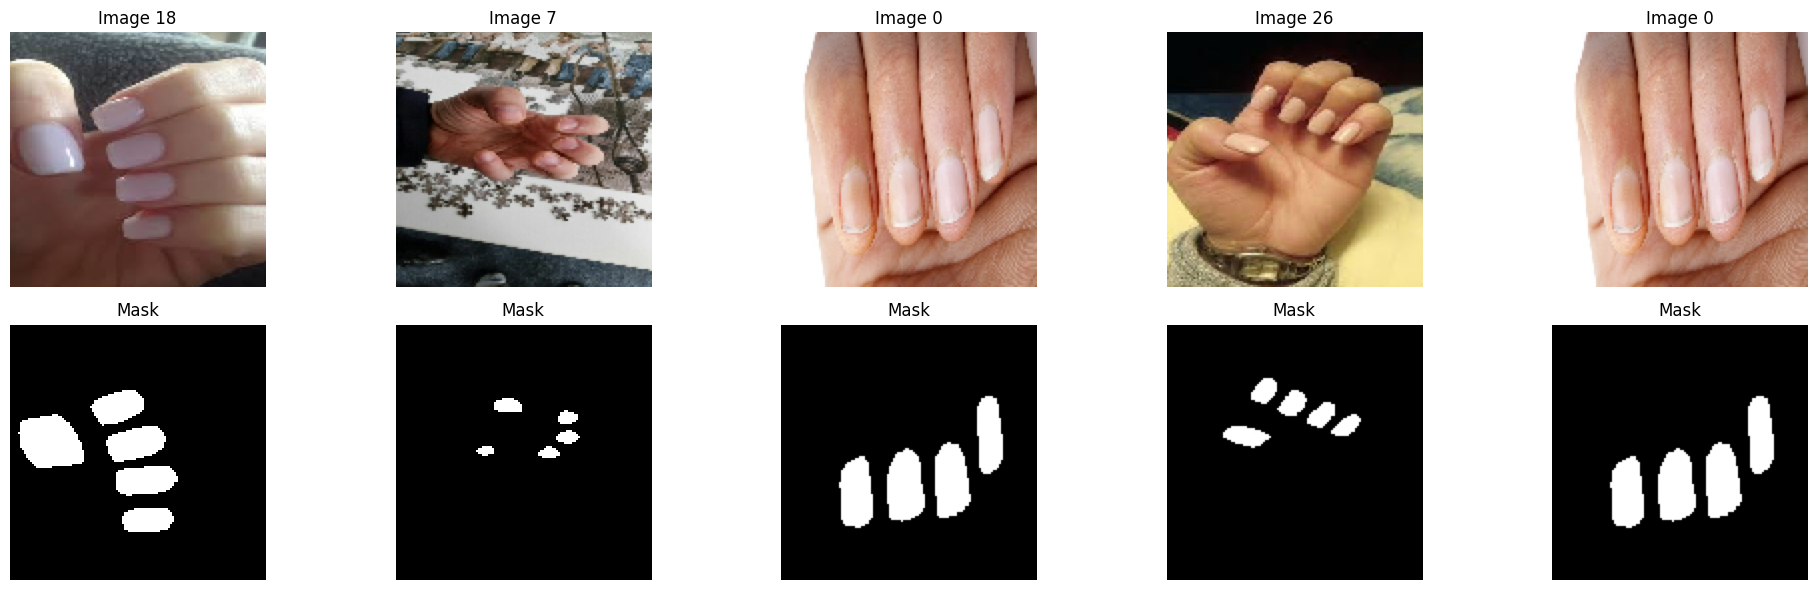

In [17]:
plot_image_and_mask(images, masks)

## Data Generator

In [18]:
def get_random_transform():
    return A.Compose([
        A.HorizontalFlip(p=random.uniform(0.3, 0.7)),
        A.VerticalFlip(p=random.uniform(0.2, 0.4)),
        A.RandomRotate90(p=random.uniform(0.3, 0.6)),
        A.ShiftScaleRotate(
            shift_limit=random.uniform(0.05, 0.15),
            scale_limit=random.uniform(0.05, 0.15),
            rotate_limit=random.randint(10, 25),
            p=0.5
        ),
        A.RandomBrightnessContrast(
            brightness_limit=random.uniform(0.1, 0.4),
            contrast_limit=random.uniform(0.1, 0.4),
            p=random.uniform(0.2, 0.5)
        ),
        A.GaussNoise(
            p=random.uniform(0.1, 0.3)
        )
    ])


In [ ]:
class DataGenerator(Sequence):
    def __init__(self, image_paths, mask_paths, batch_size=16, augment=True, shuffle=True):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.batch_size = batch_size
        self.augment = augment
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.image_paths))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __getitem__(self, index):
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        batch_image_paths = [self.image_paths[k] for k in indexes]
        batch_mask_paths = [self.mask_paths[k] for k in indexes]

        X, y = self.__data_generation(batch_image_paths, batch_mask_paths)
        return X, y

    def __data_generation(self, batch_image_paths, batch_mask_paths):
        X = []
        y = []

        if self.augment:
          transform = get_random_transform()

        for img_path, mask_path in zip(batch_image_paths, batch_mask_paths):
          image = load_image(img_path)
          mask = load_image(mask_path, color_mode='grayscale')

          if self.augment:
            augmented = transform(image=image, mask=mask)

            image = augmented['image']
            mask = augmented['mask']

          X.append(image)
          y.append(mask)

        return np.array(X), np.array(y)


In [20]:
X_train_paths, X_temp_paths, y_train_paths, y_temp_paths = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42
)
X_val_paths, X_test_paths, y_val_paths, y_test_paths = train_test_split(
    X_temp_paths, y_temp_paths, test_size=0.5, random_state=42
)

train_gen = DataGenerator(X_train_paths, y_train_paths, batch_size=16, augment=True)
val_gen = DataGenerator(X_val_paths, y_val_paths, batch_size=16, augment=False)
test_gen = DataGenerator(X_test_paths, y_test_paths, batch_size=1, augment=False, shuffle=False)


## Baseline - Полносвязанная нейронная сеть

In [21]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def dice_bce_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice



In [22]:
input_shape = (128, 128, 3)
output_shape = (128, 128, 1)

sequential_model = Sequential([
    Flatten(input_shape=input_shape),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(np.prod(output_shape), activation='sigmoid'),
    Reshape(output_shape)
])

sequential_model.compile(
    optimizer='adam',
    loss=dice_bce_loss,
    metrics=['accuracy', dice_coef, iou_coef, Precision(), Recall()]
)
# sequential_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
sequential_history = sequential_model.fit(train_gen, validation_data=val_gen, epochs=100)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5663 - dice_coef: 0.0899 - iou_coef: 0.0472 - loss: 1.5811 - precision: 0.0524 - recall: 0.4304 - val_accuracy: 0.8719 - val_dice_coef: 0.0445 - val_iou_coef: 0.0228 - val_loss: 1.3037 - val_precision: 0.0304 - val_recall: 0.1429
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 381ms/step - accuracy: 0.8826 - dice_coef: 0.1044 - iou_coef: 0.0553 - loss: 1.2416 - precision: 0.0815 - recall: 0.0937 - val_accuracy: 0.9660 - val_dice_coef: 0.0725 - val_iou_coef: 0.0376 - val_loss: 1.0765 - val_precision: 0.1049 - val_recall: 0.0578
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 307ms/step - accuracy: 0.9338 - dice_coef: 0.0967 - iou_coef: 0.0509 - loss: 1.1844 - precision: 0.0953 - recall: 0.0328 - val_accuracy: 0.9398 - val_dice_coef: 0.0803 - val_iou_coef: 0.0418 - val_loss: 1.1163 - val_precision: 0.0847 - val_recall: 0.1573
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 300ms/step - accuracy: 0.9098 - dice_coef: 0.1093 - iou_coef: 0.0579 - loss: 1

## Реализация U-Net

In [41]:
def conv_block(inputs, num_filters):
    x = layers.Conv2D(num_filters, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    x = layers.Conv2D(num_filters, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(x)
    return x


In [42]:
def encoder_block(inputs, num_filters):
    x = conv_block(inputs, num_filters)
    p = layers.MaxPooling2D((2, 2))(x)
    return x, p


In [43]:
def decoder_block(inputs, skip_features, num_filters):
    x = layers.Conv2DTranspose(num_filters, (2, 2), strides=(2, 2), padding='same')(inputs)
    x = layers.concatenate([x, skip_features])
    x = conv_block(x, num_filters)
    return x

In [44]:
def build_unet(input_shape=(128, 128, 3), num_classes=1):
    inputs = layers.Input(shape=input_shape)

    # --- Encoder ---
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # --- Bottleneck ---
    b1 = conv_block(p4, 1024)

    # --- Decoder ---
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    # --- Output ---
    outputs = layers.Conv2D(num_classes, (1, 1), activation='sigmoid')(d4)

    model = models.Model(inputs, outputs, name="U-Net")

    return model

In [50]:
unet_model = build_unet(input_shape=(128, 128, 3), num_classes=1)

unet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy', #dice_bce_loss,
    metrics=['accuracy', dice_coef, iou_coef, Precision(), Recall()]
)


In [51]:
# --- Обучение ---
unet_history = unet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=500
)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.7981 - dice_coef: 0.0548 - iou_coef: 0.0286 - loss: 0.9214 - precision_6: 0.0542 - recall_6: 0.1684 - val_accuracy: 0.9763 - val_dice_coef: 0.0248 - val_iou_coef: 0.0125 - val_loss: 0.2896 - val_precision_6: 0.0000e+00 - val_recall_6: 0.0000e+00
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 316ms/step - accuracy: 0.9453 - dice_coef: 0.0393 - iou_coef: 0.0201 - loss: 0.3495 - precision_6: 0.0000e+00 - recall_6: 0.0000e+00 - val_accuracy: 0.9763 - val_dice_coef: 0.0135 - val_iou_coef: 0.0068 - val_loss: 0.2242 - val_precision_6: 0.0000e+00 - val_recall_6: 0.0000e+00
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 368ms/step - accuracy: 0.9489 - dice_coef: 0.0151 - iou_coef: 0.0076 - loss: 0.4137 - precision_6: 0.0000e+00 - recall_6: 0.0000e+00 - val_accuracy: 0.9763 - val_dice_coef: 0.0216 - val_iou_coef: 0.0109 - val_loss: 0.2633 - val_precision_6: 0.0000e+00 - val_recall_6: 0.0000e+00
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 352ms/step - 

## Сравнение результатов

In [30]:
X_test = np.array([load_image(path) for path in X_test_paths])
y_test = np.array([load_image(path, color_mode='grayscale') for path in y_test_paths])

### Baseline

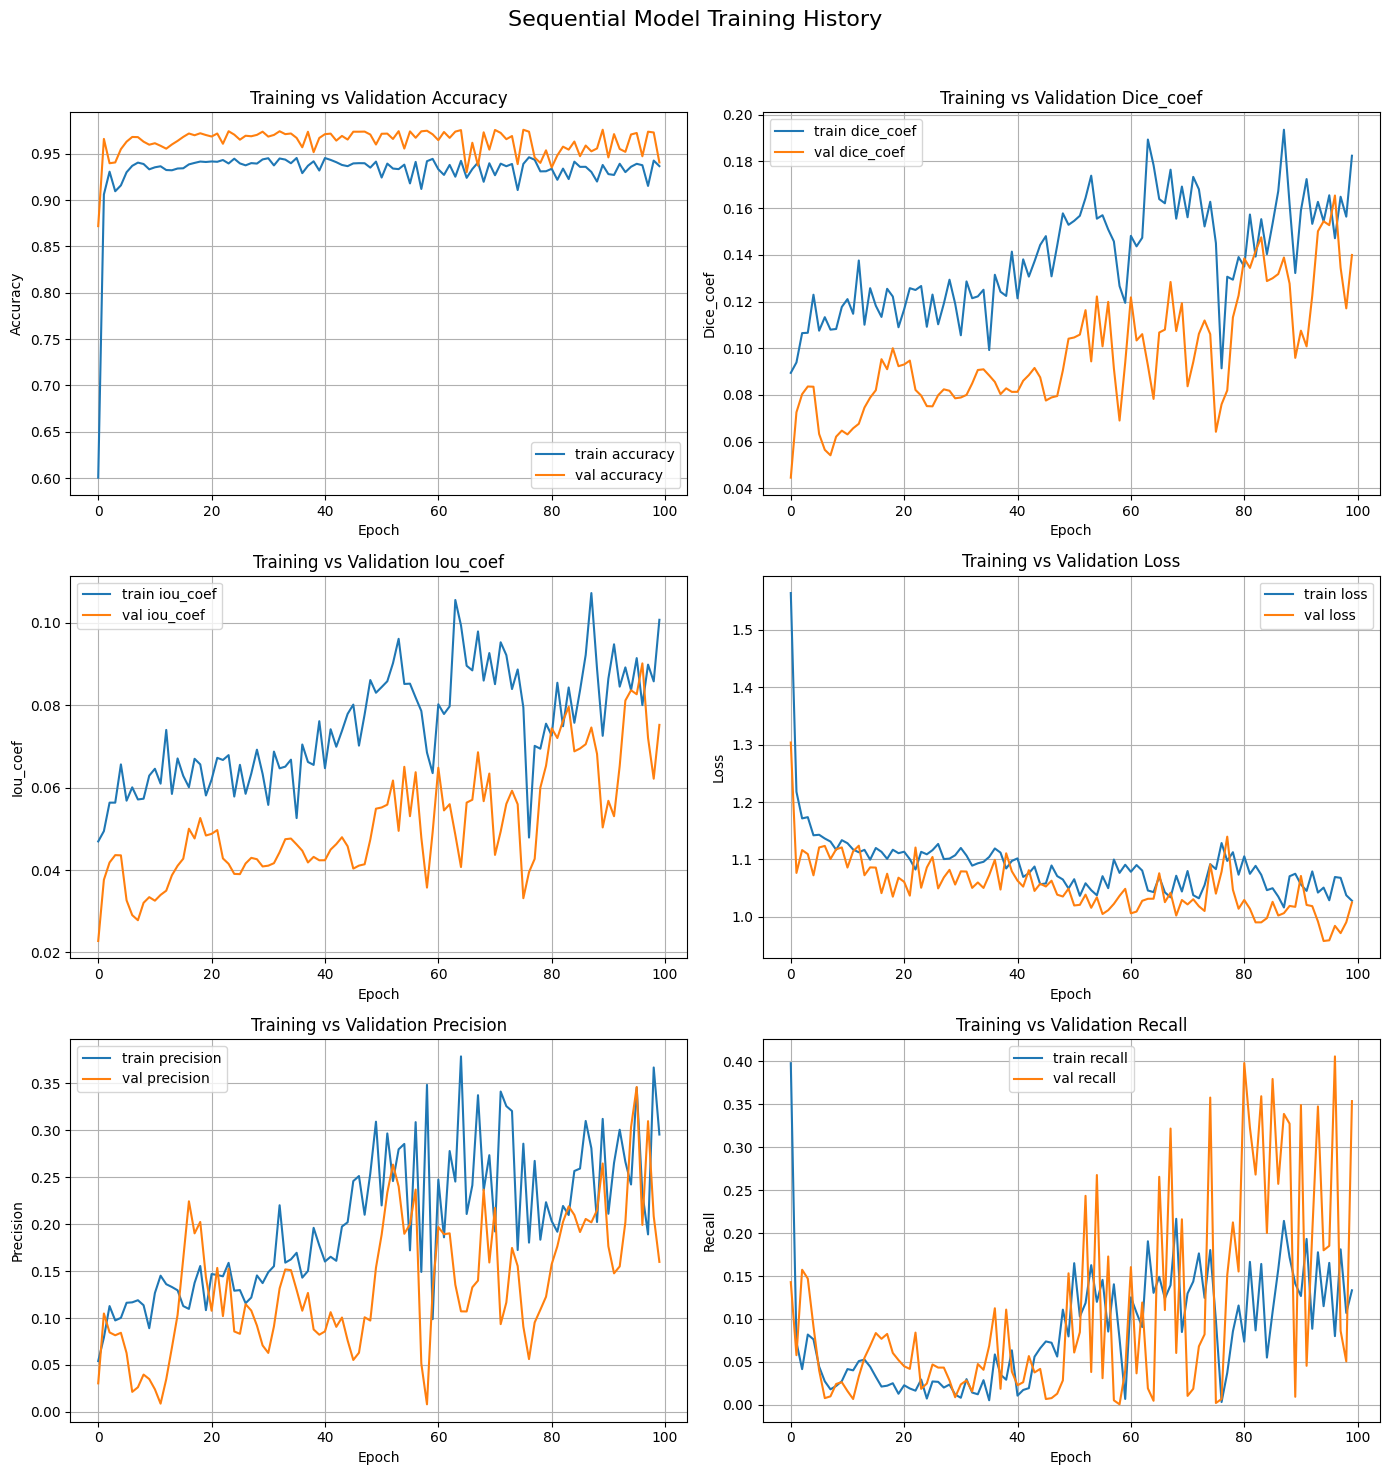

In [31]:
plot_training_history(sequential_history, title = "Sequential Model Training History")

In [32]:
seq_y_pred = sequential_model.predict(test_gen, verbose=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


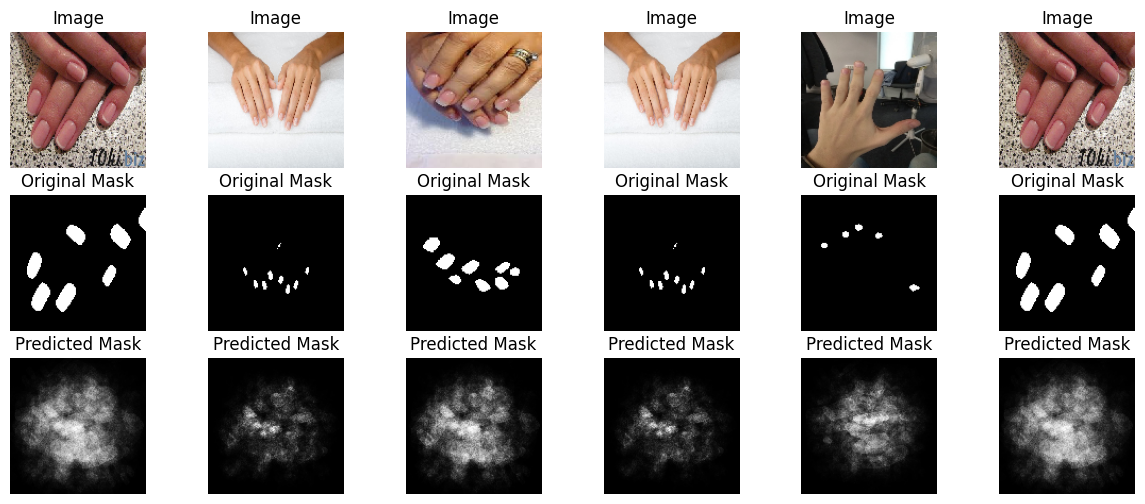

In [33]:
plot_predictions(X_test, y_test, seq_y_pred)

### U-Net

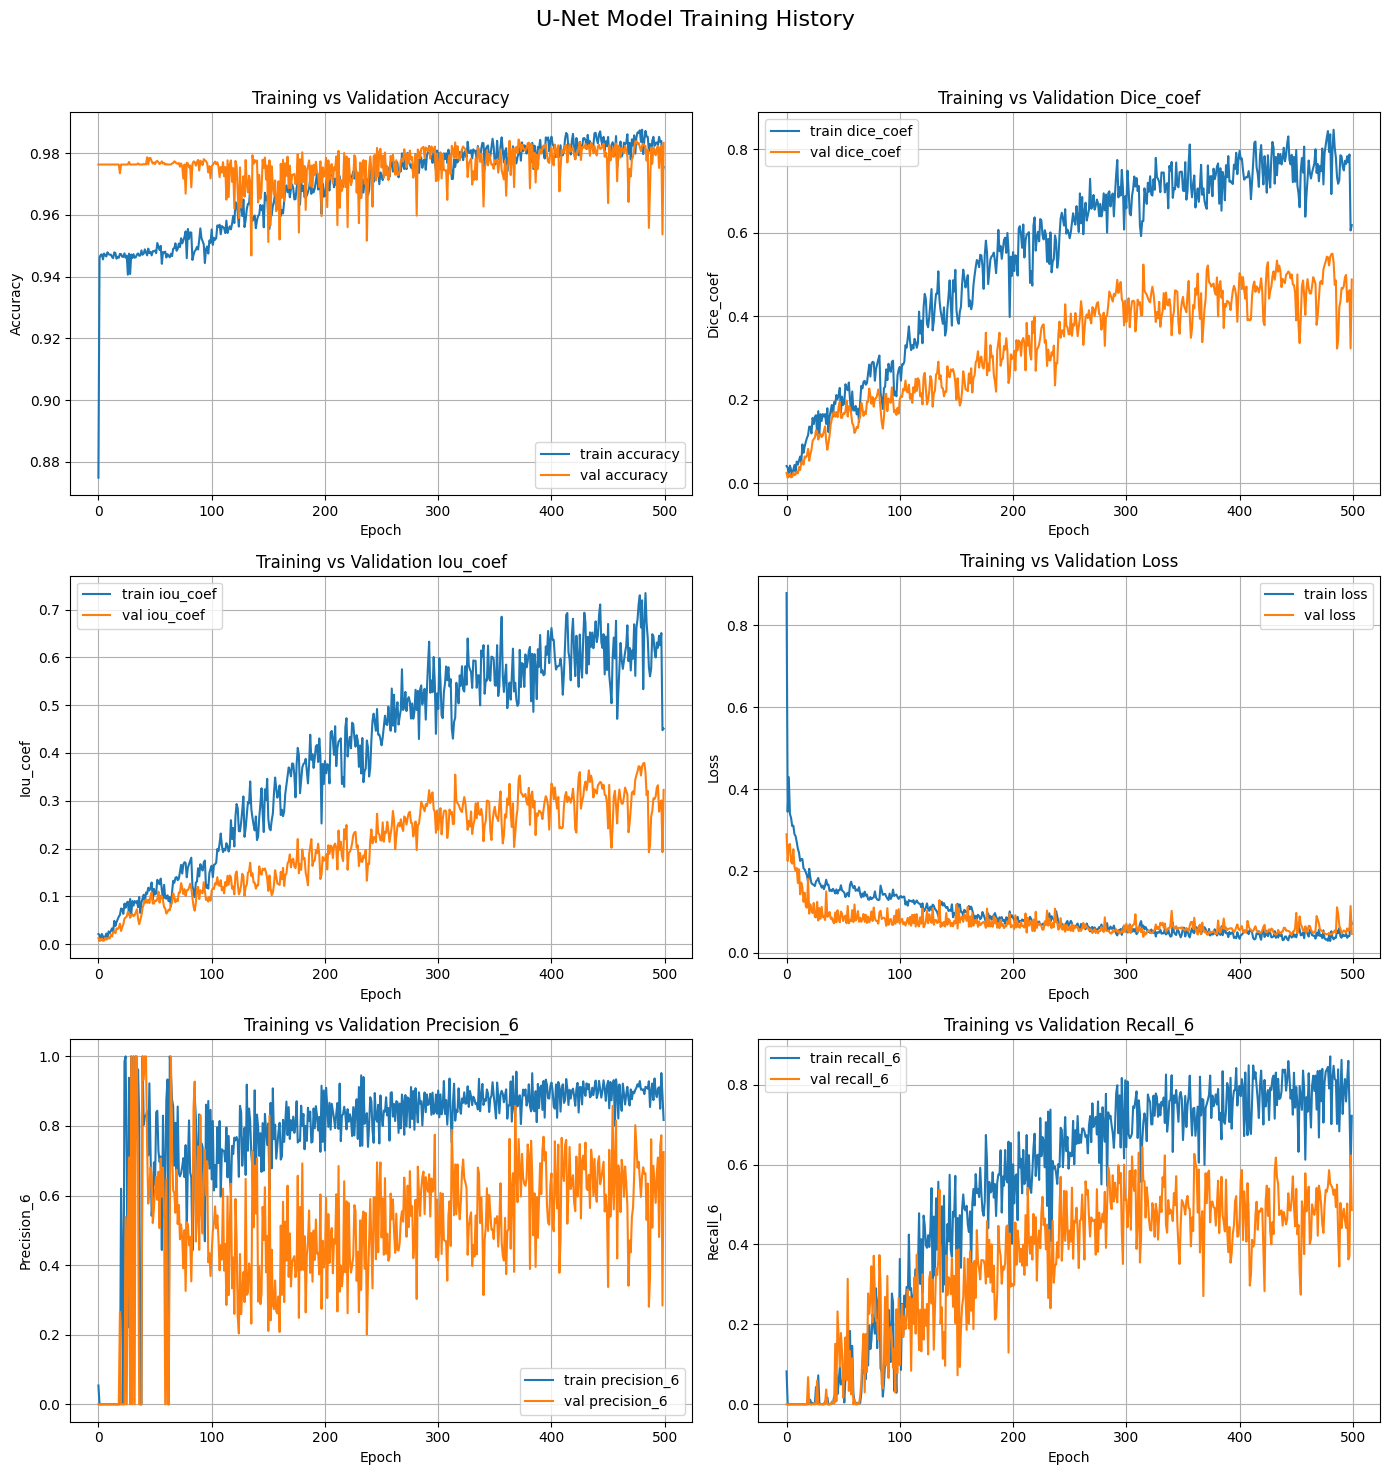

In [52]:
plot_training_history(unet_history, title = "U-Net Model Training History")

In [53]:
unet_y_pred = unet_model.predict(test_gen, verbose=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


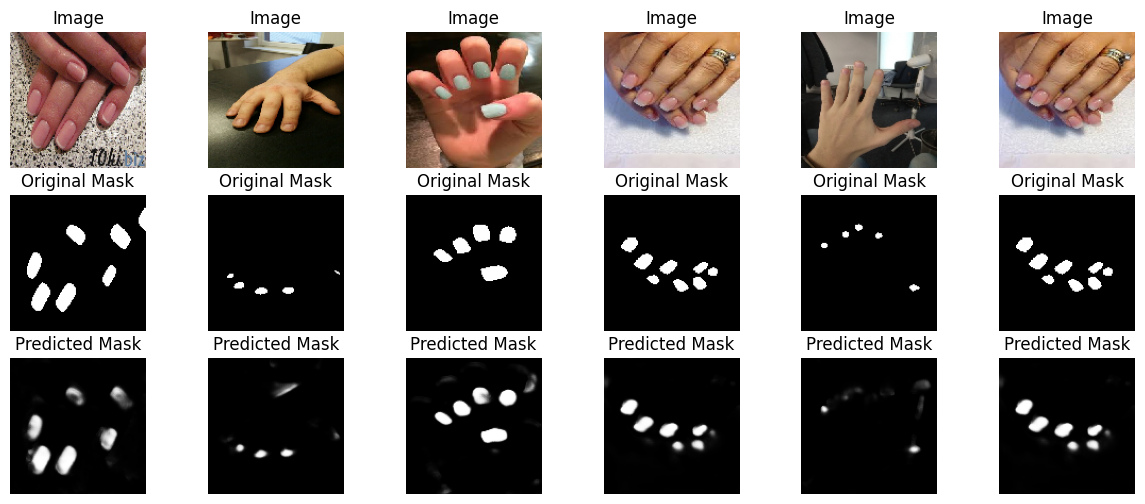

In [57]:
plot_predictions(X_test, y_test, unet_y_pred)

In [ ]:
y_true = []
for i in range(len(test_gen)):
    _, y = test_gen[i]
    y_true.append(y)

y_true = np.concatenate(y_true)


In [65]:
y_true = (y_true > 0.5).astype(np.uint8)
y_pred = (unet_y_pred > 0.5).astype(np.uint8)


In [67]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Преобразуем в 1D
y_true_flat = y_true.flatten()
y_pred_flat = y_pred.flatten()

precision = precision_score(y_true_flat, y_pred_flat)
recall = recall_score(y_true_flat, y_pred_flat)
f1 = f1_score(y_true_flat, y_pred_flat)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")


Precision: 0.8561
Recall:    0.6821
F1-score:  0.7593


In [69]:
unet_model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 128, 128,  │      1,792 │ input_layer_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_95[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 64, 64,    │          0 │ conv2d_96[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_20… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_97[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 32, 32,    │          0 │ conv2d_98[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_99 (Conv2D)  │ (None, 32, 32,    │    295,168 │ max_pooling2d_21… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_100 (Conv2D) │ (None, 32, 32,    │    590,080 │ conv2d_99[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_22    │ (None, 16, 16,    │          0 │ conv2d_100[0][0]  │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_101 (Conv2D) │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_22… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_102 (Conv2D) │ (None, 16, 16,    │  2,359,808 │ conv2d_101[0][0]  │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_23    │ (None, 8, 8, 512) │          0 │ conv2d_102[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_103 (Conv2D) │ (None, 8, 8,      │  4,719,616 │ max_pooling2d_23… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_104 (Conv2D) │ (None, 8, 8,      │  9,438,208 │ conv2d_103[0][0]  │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_20 │ (None, 16, 16,    │  2,097,664 │ conv2d_104[0][0]  │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_20      │ (None, 16, 16,    │          0 │ conv2d_transpose

 Total params: 93,095,237 (355.13 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,063,492 (236.75 MB)

In [58]:
unet_model.save("unet_model.keras")


In [59]:
!zip -r /content/unet.zip /content/unet_model.keras

  adding: content/unet_model.keras (deflated 12%)


In [60]:
from google.colab import files
files.download("/content/unet.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>